![plotly.jpg](attachment:6a89da5d-548b-424f-aab7-3bf9242b01c0.jpg)

- A JavaScript graphing library - but we can write by Python code
- Plotly has a Python wrapper

**Why Plotly?**
- Fast and easy to use
- Low code, low effort options using plotly.express
- Extremely customization, interactive

**Creating the Figure**

In [ ]:
# !pip install plotly==6.1.1

In [ ]:
import plotly.express as px

In [ ]:
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.graph_objs as go

In [ ]:
#Create df for plot
#import plotly.io as pio
#pio.renderers.default = "notebook"
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temperature = [28, 25, 26, 24, 32, 35, 36]

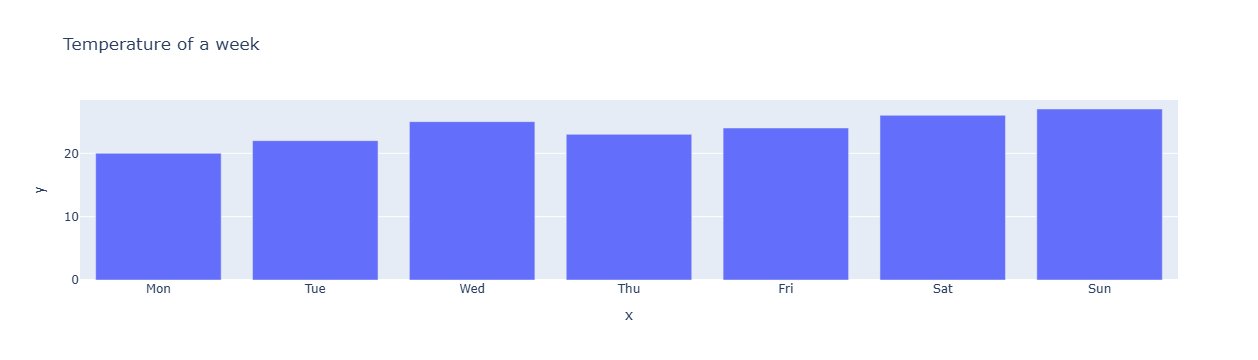

In [ ]:
import plotly.express as px
#import plotly.io as pio
#pio.renderers.default = "notebook"   # hoặc "iframe"

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
temperature = [20, 22, 25, 23, 24, 26, 27]

fig = px.bar(x=days, y=temperature, title='Temperature of a week')
fig.show()

**The Plotly Figure**

- `layout`: Dictionary controlling style of the Figure
 --> one `layout` per figure
- `data`: List of dictionaries setting graph type and data itself
      + Data + type = a`trace`. There are over 40 types
      + Can have multiple traces per graph
- `frames`: For animated plots

**Plotly's instant interactivity**
- Hover over data points
- Extra interactive buttions

![plotly interactivity.jpg](attachment:9684f7e8-df70-4f92-ae05-743e31697c7f.jpg)

# Bar and line chart

You are working for a global e-commerce company that has been using third-party software to build in-house graphics for reporting. They are wondering if open-somurce libraries would provide better graphics for their reporting purposes.

You jump at the opportunity to design a slick (and interactive!) visual with Plotly. Your first task will be to update their basic line figure, which visualizes the total sales by month and country

In [ ]:
import pandas as pd
import plotly.express as px

In [ ]:
# load data
ecom_sales = pd.read_csv('5ecom_sales.csv').drop('Unnamed: 0', axis=1)
ecom_sales.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   InvoiceNo       700 non-null    int64  
 1   UnitPrice       700 non-null    float64
 2   OrderValue      700 non-null    float64
 3   Quantity        700 non-null    int64  
 4   Country         700 non-null    object 
 5   InvoiceDate     700 non-null    object 
 6   InvoiceTime     700 non-null    object 
 7   Year-Month      700 non-null    object 
 8   Major Category  700 non-null    object 
 9   Minor Category  700 non-null    object 
 10  Description     700 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 60.3+ KB


1. Create line chart for order value each country per month

In [ ]:
ecom_sales.head()

,InvoiceNo,UnitPrice,OrderValue,Quantity,Country,InvoiceDate,InvoiceTime,Year-Month,Major Category,Minor Category,Description
0,549185,0.85,10.20,12,United Kingdom,7/4/11,09:35,2011-04,Clothes,Tops,PACK OF 20 NAPKINS PANTRY DESIGN
1,576381,2.95,35.40,12,United Kingdom,15/11/11,09:26,2011-11,Clothes,Shoes,NATURAL SLATE HEART CHALKBOARD
2,551192,1.25,20.00,16,United Kingdom,27/4/11,10:54,2011-04,Kitchen,Cutlery,36 PENCILS TUBE SKULLS
3,573553,7.46,7.46,1,United Kingdom,31/10/11,13:48,2011-10,Garden,Turf,SET 6 SCHOOL MILK BOTTLES IN CRATE
4,539436,2.51,2.51,1,United Kingdom,17/12/10,14:49,2010-12,Garden,Hoses,FINE WICKER HEART


In [ ]:
ecom_sales.Country.nunique()

5

In [ ]:
ecom_sales.columns

Index(['InvoiceNo', 'UnitPrice', 'OrderValue', 'Quantity', 'Country',
       'InvoiceDate', 'InvoiceTime', 'Year-Month', 'Major Category',
       'Minor Category', 'Description'],
      dtype='object')

In [ ]:
ecom_sales_group = ecom_sales.groupby(['Year-Month','Country'])['OrderValue'].agg('sum').reset_index(name = 'Total Sales')

In [ ]:
ecom_sales_group

,Year-Month,Country,Total Sales
0,2010-12,Australia,147.50
1,2010-12,France,128.33
2,2010-12,Germany,227.70
3,2010-12,United Kingdom,291.81
4,2011-01,Australia,471.30
5,2011-01,France,576.29
6,2011-01,Germany,279.10
7,2011-01,Hong Kong,595.80
8,2011-01,United Kingdom,157.76
9,2011-02,Australia,511.94


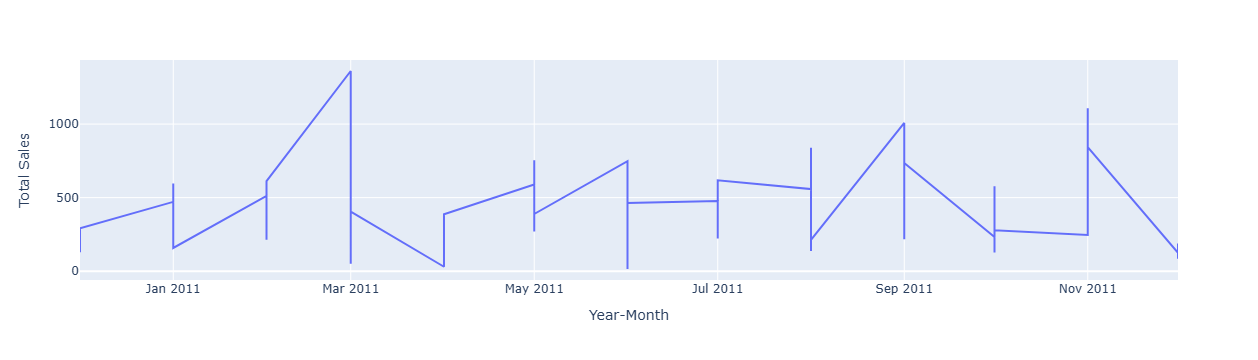

In [ ]:
line_graph = px.line(
    data_frame = ecom_sales_group, x ='Year-Month',y = 'Total Sales')

line_graph.show()

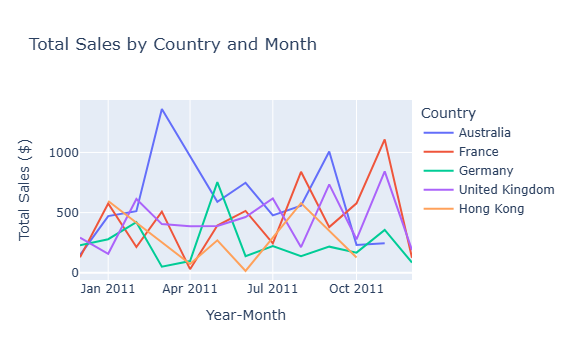

In [ ]:

# Group data: Total Sales by Year-Month and Country
ecom_sales_group = (
    ecom_sales
    .groupby(['Year-Month', 'Country'], as_index=False)['OrderValue']
    .sum()
)

# Create line chart
line_graph = px.line(
    data_frame=ecom_sales_group,
    x='Year-Month',
    y='OrderValue',
    color='Country',
    title='Total Sales by Country and Month',
    labels={'OrderValue': 'Total Sales ($)'}
)

line_graph.show()


2. Create the bar chart and set it horizontal

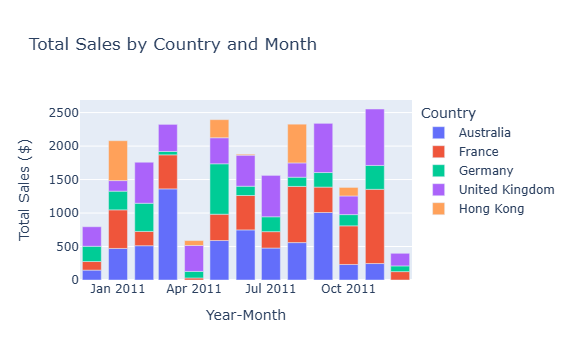

In [ ]:
line_graph = px.bar(
    data_frame=ecom_sales_group,
    x='Year-Month',
    y='OrderValue',
    color='Country',
    title='Total Sales by Country and Month',
    labels={'OrderValue': 'Total Sales ($)'}
)

line_graph.show()

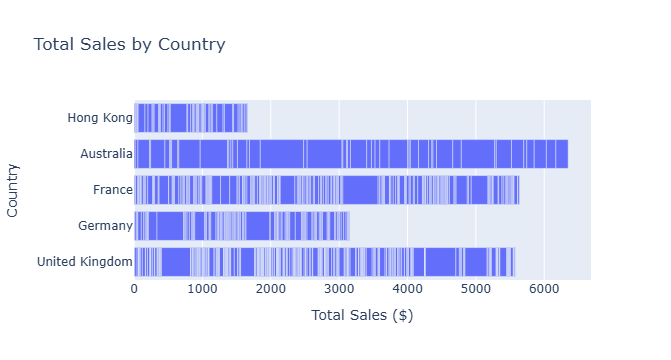

In [ ]:
import plotly.express as px

bar_fig = px.bar(
    data_frame=ecom_sales,
    x='OrderValue',          # ✅ cột thật
    y='Country',
    orientation='h',
    title='Total Sales by Country',
    labels={'OrderValue': 'Total Sales ($)'}   # 👈 chỉ là nhãn
)

bar_fig.show()


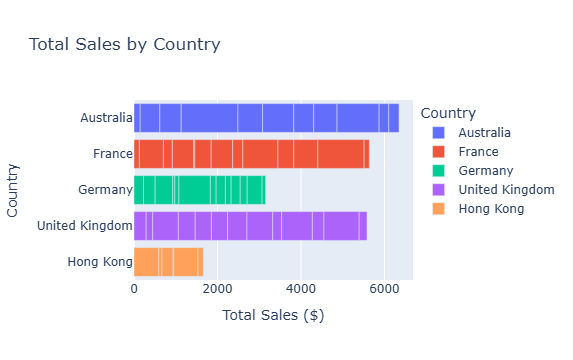

In [ ]:
import plotly.express as px

bar_graph = px.bar(
    data_frame=ecom_sales_group,
    x='OrderValue',          # giá trị nằm trên trục X
    y='Country',             # category nằm trên trục Y
    color='Country',
    orientation='h',         #  bar nằm ngang
    title='Total Sales by Country',
    labels={'OrderValue': 'Total Sales ($)'}
)

bar_graph.show()


# Histogram
Multiple columns (called bins) representing a range of values
The height of each bar = count of samples within that bin range

In [ ]:
revenues = pd.read_csv('5revenues_plotly.csv').drop('Unnamed: 0', axis=1)

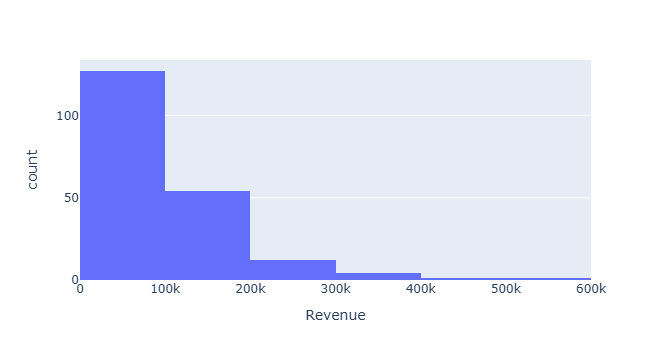

In [ ]:
fig = px.histogram(data_frame = revenues, x = 'Revenue', nbins = 5)
fig.show()

Arguments
- Orientation: to orient the plot vertically (v) or horizontally (h)
- histfunc: set the bin aggregation (eg: average, min, max)


# Box (whisker)plots
Summarize a variable using quartile calculations
- Middle area represents interquartile range
- Top line = 3rd quartile (75th percentile)
- Bottom line = first quartile (25th percentile)
- Top/bottom bars = min/max, excluding outliers


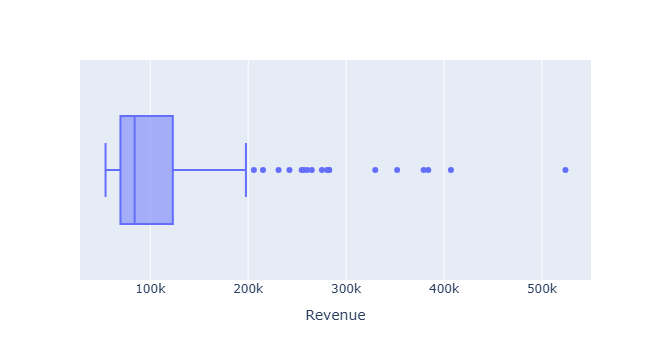

In [ ]:
fig = px.box(data_frame = revenues, x='Revenue')
fig.show()

Arguments
- `hover_data`: a list of column names to display on hover
  --> useful to understandd outliers
- `points`: further specify how to show outliers

# Customize color
How to customize plots
- At plot creation, add an argument
- After plot is created use update_layout()
      + Take a dictionary
      + fig.update_layout({'title': {'text': 'A new title'}})
Some color theory
- Computers use RGB encoding to specify colors. RGB = A3-digit code (each 0 - 255) mixing Red, Green, Blue
- Color argument (DataFrame column): each category gets a color automatically
- A color scale is used for numerical columns
Specific colors in plotly.express
- Color_discrete map: a dictionary that maps categorical values to colors
- Color scales: single color scales (light to dark); blended gradient (green into blue), color_continuous scale

In [ ]:
revenues = pd.read_csv('5revenues_plotly.csv')

In [ ]:
revenues.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   Rank        200 non-null    int64  
 2   Company     200 non-null    object 
 3   Revenue     199 non-null    float64
 4   employees   5 non-null      float64
 5   Industry    200 non-null    object 
 6   age         200 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 11.1+ KB


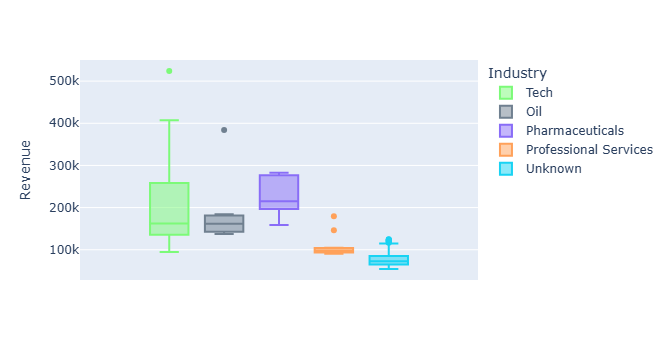

In [ ]:
#Revenue box plot with color

# Create the industry-color map
ind_color_map = {'Tech':"rgb( 124,250,120 )",
                 'Oil' : "rgb(112,128,144)",
                 'Pharmaceuticals' : "rgb(137,109,247)",
                 'Professional Servies':"rgb(255,0,0)"}



# Create a box plot
fig = px.box(data_frame = revenues , y='Revenue',
             color_discrete_map = ind_color_map,
             color = 'Industry')


# Show the plot
fig.show()


In [ ]:
#Revenue histogram with stacked bars
# Create the industry-color map

# Create a histogram


# Show the plot



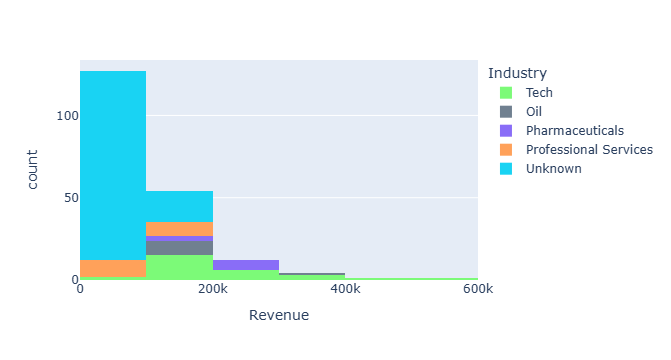

In [ ]:




# Create a box plot
fig = px.histogram(data_frame = revenues , x='Revenue', nbins = 5,
             color_discrete_map = ind_color_map,
             color = 'Industry')


# Show the plot
fig.show()
